In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
import numpy as np

In [57]:
adata =sc.read('data/sim_anndata_5000_cells_2000_genes_4_factors_0_seed_gene_sets_formatted_MS_0_EX_0.h5ad')

In [58]:
print('Genes in the pathway')
gene_in_pathway = np.where(adata.var['DEFac_1'] !=1.0)[0]
print(gene_in_pathway)

Genes in the pathway
[  0   1   4   5   6   8   9  16  17  19  21  22  24  27  28  29  31  32
  33  36  45  47  51  52  53  59  60  67  69  73  76  79  80  85  88  89
  90  96  98  99 104 105 106 110 111 114 120 122 123 126 128 129 133 134
 136 139 140 141 147 148 150 151 153 155 157 159 162 166 167 170 173 178
 181 183 185 186 190 194 197 208 210 211 213 214 218 223 224 225 228 229
 230 233 234 238 240 241 242 243 245 248 249 251 253 256 264 267 271 277
 279 281 283 287 288 289 291 292 295 296 297 304 305 306 313 314 322 323
 325 333 334 335 336 342 348 350 351 356 357 361 362 364 365 368 371 373
 378 379 380 381 382 385 387 390 391 392 393 395 396 397 398 399 400 405
 408 409 410 412 414 421 430 433 434 435 436 438 442 445 446 447 451 453
 454 456 458 460 462 464 467 474 482 484 485 488 493 494]


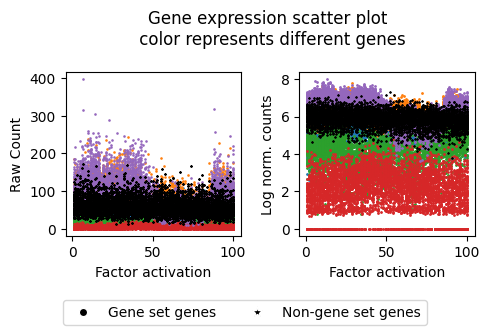

In [59]:



fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))  # adjust size as needed
fig.text(0.55, 1.0, 'Gene expression scatter plot \n color represents different genes', ha='center', fontsize=12)

# Plot gene set genes (first 5)
for i in [4,5,6,8,9]:
    axes[0].scatter(adata.obs['steps_1'], adata.X[:, i], s=0.75)
    axes[1].scatter(adata.obs['steps_1'], adata.layers['logcounts'][:, i], s=1)

# Plot non-gene set genes (201–204) in black stars
for i in [3]:
    axes[0].scatter(adata.obs['steps_1'], adata.X[:, i], s=1, marker='*', c='k')
    axes[1].scatter(adata.obs['steps_1'], adata.layers['logcounts'][:, i], s=0.75, marker='*', c='k')

# Set titles and labels
axes[0].set_xlabel("Factor activation")
axes[0].set_ylabel("Raw Count")

axes[1].set_xlabel("Factor activation")
axes[1].set_ylabel("Log norm. counts")

# Create custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Gene set genes',
           markerfacecolor='k', markersize=6),
    Line2D([0], [0], marker='*', color='w', label='Non-gene set genes',
           markerfacecolor='k', markersize=8)
]

# Add legend to the right of the second axis
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.15))
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.savefig('figures/sim_nonlinear_gene_expression_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [60]:
sc.tl.pca(adata, layer ='logcounts')

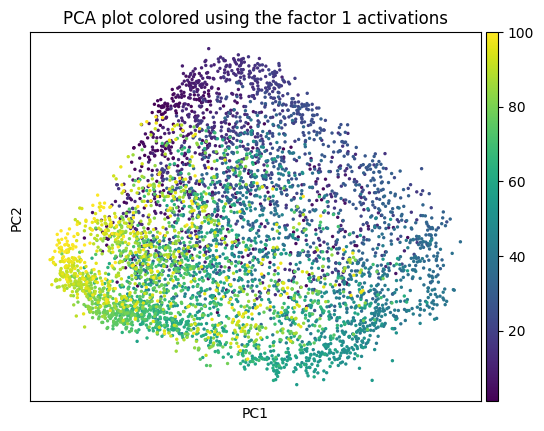

In [77]:
sc.settings.figdir = 'figures/'  # set custom directory

sc.pl.pca(adata, color  ='steps_1', title = 'PCA plot colored using the factor 1 activations', save= '_sim_pca_plot_sim_data_shuffle_param_0p4.png')


In [75]:
help(sc.pl.pca
    )

Help on function pca in module scanpy.plotting._tools.scatterplots:

pca(adata: anndata._core.anndata.AnnData, *, color: str | collections.abc.Sequence[str] | None = None, mask_obs: numpy.ndarray[typing.Any, numpy.dtype[numpy.bool_]] | str | None = None, gene_symbols: str | None = None, use_raw: bool | None = None, sort_order: bool = True, edges: bool = False, edges_width: float = 0.1, edges_color: str | collections.abc.Sequence[float] | collections.abc.Sequence[str] = 'grey', neighbors_key: str | None = None, arrows: bool = False, arrows_kwds: collections.abc.Mapping[str, typing.Any] | None = None, groups: str | collections.abc.Sequence[str] | None = None, components: str | collections.abc.Sequence[str] | None = None, dimensions: tuple[int, int] | collections.abc.Sequence[tuple[int, int]] | None = None, layer: str | None = None, projection: Literal['2d', '3d'] = '2d', scale_factor: float | None = None, color_map: matplotlib.colors.Colormap | str | None = None, cmap: matplotlib.colors.